# Feature Scaling

## What is Feature Scaling?

Feature Scaling is a preprocessing technique used to bring numerical features to a similar scale without changing the underlying relationships in the data.

### Example

| Age | Salary |
|------|---------|
| 25 | 50,000 |
| 35 | 75,000 |

Since Salary has a much larger range than Age, some algorithms may give it more importance. Feature scaling solves this problem.

---

## Why Do We Need Feature Scaling?

- Prevents features with large values from dominating smaller ones.
- Helps Gradient Descent converge faster.
- Improves performance of distance-based algorithms.
- Makes numerical computations more stable.
- Ensures fair contribution of all features.

---

## Advantages

- Faster model training.
- Better model performance.
- Improved distance calculations.
- Fair feature importance.
- Better numerical stability.

---

## Disadvantages

- Reduced interpretability of feature values.
- Adds an extra preprocessing step.
- Some methods are sensitive to outliers.
- Not needed for tree-based models.

---

## Common Feature Scaling Methods

### 1. Min-Max Scaling (Normalization)

Scales data to a fixed range, usually [0, 1].

**Formula**

$$
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

**Pros**
- Fixed range.
- Good for Neural Networks.

**Cons**
- Highly sensitive to outliers.

---

### 2. Standardization (Z-Score Scaling)

Transforms data so that mean = 0 and standard deviation = 1.

**Formula**

$$
z = \frac{x - \mu}{\sigma}
$$

where:
- $\mu$ = Mean
- $\sigma$ = Standard Deviation

**Pros**
- Most commonly used.
- Works well for many ML algorithms.

**Cons**
- Does not produce a fixed range.

---

### 3. Robust Scaling

Uses Median and IQR instead of Mean and Standard Deviation.

**Formula**

$$
x_{scaled} = \frac{x - Median}{IQR}
$$

where:

$$
IQR = Q_3 - Q_1
$$

**Pros**
- Resistant to outliers.

**Cons**
- No fixed range.

---

### 4. Max Absolute Scaling

Scales data by dividing by the maximum absolute value.

**Formula**

$$
x_{scaled} = \frac{x}{|x_{max}|}
$$

**Pros**
- Preserves sparsity.
- Useful for sparse datasets.

**Cons**
- Sensitive to outliers.

---

## Algorithms That Need Feature Scaling

- Linear Regression
- Logistic Regression
- KNN
- K-Means
- SVM
- PCA
- Neural Networks

### Usually Not Required

- Decision Trees
- Random Forest
- XGBoost
- LightGBM
- CatBoost

---

## Quick Summary

| Method | Best For |
|----------|----------|
| Standardization | General ML tasks |
| Min-Max Scaling | Neural Networks |
| Robust Scaling | Data with Outliers |
| Max Absolute Scaling | Sparse Data |

**Rule of Thumb:** Use **Standardization** unless you have a specific reason to choose another method.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("melbourne_preprocessed_data.csv")

In [28]:
df.shape

(27243, 13)

In [29]:
df.head()

,Price2,Distance_sqrt,Landsize_KNN,BuildingArea_KNN,Bathroom_mode,Age,CouncilArea_Encoded,Method_Encoded,Lattitude_impute,Longtitude_impute,Type_h,Type_t,Rooms
0,1480000.0,1.581139,202.0,156.834586,1.0,56.0,1.103285e+06,1.051479e+06,-37.7996,144.9984,1.0,0.0,2
1,1035000.0,1.581139,156.0,79.000000,1.0,116.0,1.103285e+06,1.051479e+06,-37.8079,144.9934,1.0,0.0,2
2,1465000.0,1.581139,134.0,150.000000,2.0,117.0,1.103285e+06,8.790954e+05,-37.8093,144.9944,1.0,0.0,3
3,850000.0,1.581139,94.0,156.834586,2.0,57.0,1.103285e+06,1.117884e+06,-37.7969,144.9969,1.0,0.0,3
4,1600000.0,1.581139,120.0,142.000000,1.0,2.0,1.103285e+06,1.194341e+06,-37.8072,144.9941,1.0,0.0,4


In [30]:
df.isna().sum()

Price2                 0
Distance_sqrt          0
Landsize_KNN           0
BuildingArea_KNN       0
Bathroom_mode          0
Age                    0
CouncilArea_Encoded    0
Method_Encoded         0
Lattitude_impute       0
Longtitude_impute      0
Type_h                 0
Type_t                 0
Rooms                  0
dtype: int64

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price2,27243.0,1.050205e+06,641503.424626,85000.000000,6.350000e+05,8.700000e+05,1.295000e+06,1.120000e+07
Distance_sqrt,27243.0,3.214943e+00,0.971960,0.000000,2.529822e+00,3.240370e+00,3.741657e+00,6.935416e+00
Landsize_KNN,27243.0,4.294159e+02,283.868992,0.000000,1.930000e+02,5.121715e+02,5.920000e+02,1.190500e+03
BuildingArea_KNN,27243.0,1.534799e+02,44.817807,40.460000,1.560000e+02,1.568346e+02,1.568346e+02,3.565400e+02
Bathroom_mode,27243.0,1.451749e+00,0.662019,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,9.000000e+00
Age,27243.0,4.793679e+01,27.413009,0.000000,2.800000e+01,4.700000e+01,5.800000e+01,1.970000e+02
CouncilArea_Encoded,27243.0,1.050205e+06,313905.384937,414400.000000,8.507963e+05,9.956837e+05,1.173891e+06,1.667326e+06
Method_Encoded,27243.0,1.050205e+06,80603.378298,879095.386452,1.051479e+06,1.051479e+06,1.051479e+06,1.194341e+06
Lattitude_impute,27243.0,-3.780767e+01,0.091054,-38.190430,-3.786164e+01,-3.780121e+01,-3.774860e+01,-3.739780e+01
Longtitude_impute,27243.0,1.449977e+02,0.118173,144.423790,1.449265e+02,1.450052e+02,1.450686e+02,1.455264e+02


In [34]:
X = df.drop("Price2", axis=1)
y = df["Price2"]

# Data Splitting

## Training Set

Used to train the model and learn patterns from the data.

## Validation Set

Used to tune hyperparameters and select the best model.

## Test Set

Used to evaluate the final model on unseen data.

## train_test_split()

`train_test_split()` splits a dataset into training and testing sets.

### Example

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

### Parameters

* `X` : Features
* `y` : Target variable
* `test_size` : Proportion of data used for testing
* `random_state` : Ensures reproducible results

### Common Split Ratios

* 80% Train, 20% Test
* 70% Train, 30% Test
* 70% Train, 15% Validation, 15% Test


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)  # 20% test, 80% train

<Axes: xlabel='Distance_sqrt', ylabel='Landsize_KNN'>

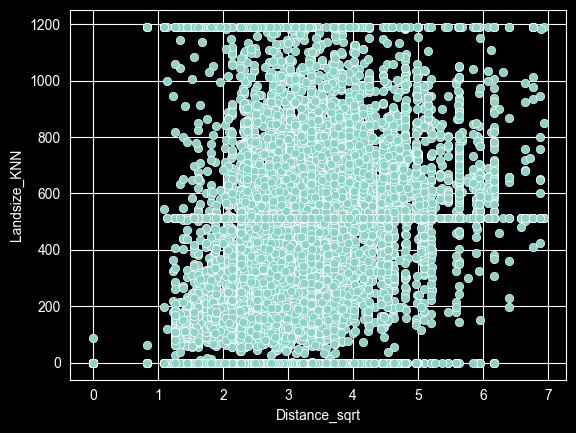

In [46]:
sns.scatterplot(data=X_train, x="Distance_sqrt", y="Landsize_KNN")

In [52]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)


Mean Squared Error: 179397482051.83636
Mean Absolute Error: 247547.18586896683
Root Mean Squared Error: 423553.39929203305


# Feature Scaling

## Standardization (Z-Score Scaling)

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

In [42]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_train_scaled.head()

,Distance_sqrt,Landsize_KNN,BuildingArea_KNN,Bathroom_mode,Age,CouncilArea_Encoded,Method_Encoded,Lattitude_impute,Longtitude_impute,Type_h,Type_t,Rooms
5799,0.632824,0.292079,0.079868,-0.677903,-0.251286,-0.295133,0.017498,-1.269818,0.754097,0.689245,-0.341483,0.012175
11724,-1.413160,-1.276178,0.079868,0.829825,-1.419512,-0.026952,0.017498,0.135953,-0.695672,-1.450862,2.928408,0.012175
14878,1.148742,-0.647705,-2.515415,0.829825,-1.200470,0.473769,0.017498,-1.319030,1.674397,0.689245,-0.341483,0.012175
22467,0.131731,-0.174585,-1.232209,-0.677903,0.697897,-0.637572,0.017498,1.062539,-0.774397,0.689245,-0.341483,0.012175
1472,0.131731,2.687084,3.384122,2.337553,2.851813,1.673670,1.782339,-1.264338,-0.037988,0.689245,-0.341483,2.126540


In [49]:
X_test_scaled = scaler.transform(X_test)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

<Axes: xlabel='Distance_sqrt', ylabel='Landsize_KNN'>

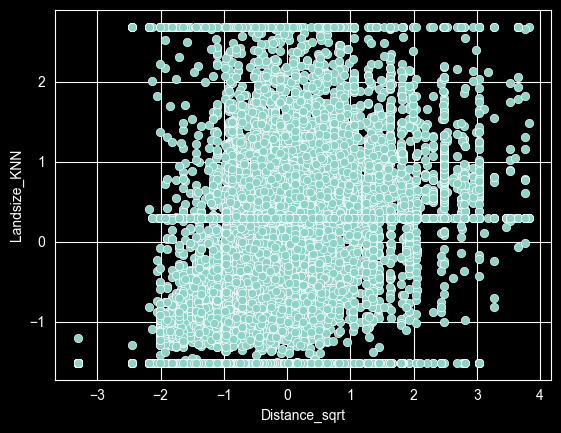

In [45]:
sns.scatterplot(data=X_train_scaled, x="Distance_sqrt", y="Landsize_KNN")

In [54]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_std_scaled = mean_squared_error(y_test, y_pred)
mae_std_scaled = mean_absolute_error(y_test, y_pred)
rmse_std_scaled = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Squared Error:", mse_std_scaled)
print("Mean Absolute Error:", mae_std_scaled)
print("Root Mean Squared Error:", rmse_std_scaled)


Mean Squared Error: 124953518314.74266
Mean Absolute Error: 200204.82055423013
Root Mean Squared Error: 353487.6494514945


In [59]:
results = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE"],
    "Without Scaling": [mse, mae, rmse],
    "With Scaling": [mse_std_scaled, mae_std_scaled, rmse_std_scaled]
})

results["Without Scaling"] = results["Without Scaling"].map("{:,.2f}".format)
results["With Scaling"] = results["With Scaling"].map("{:,.2f}".format)

print(results)

  Metric     Without Scaling        With Scaling
0    MSE  179,397,482,051.84  124,953,518,314.74
1    MAE          247,547.19          200,204.82
2   RMSE          423,553.40          353,487.65


## Min-Max Scaling (Normalization)

In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [61]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_min_max_scaled = mean_squared_error(y_test, y_pred)
mae_min_max_scaled = mean_absolute_error(y_test, y_pred)
rmse_min_max_scaled = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Squared Error:", mse_min_max_scaled)
print("Mean Absolute Error:", mae_min_max_scaled)
print("Root Mean Squared Error:", rmse_min_max_scaled)

Mean Squared Error: 128479054749.74905
Mean Absolute Error: 202299.12875757017
Root Mean Squared Error: 358439.75051568856


In [63]:
results = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE"],
    "Without Scaling": [mse, mae, rmse],
    "With Scaling": [mse_min_max_scaled, mae_min_max_scaled, rmse_min_max_scaled]
})

results["Without Scaling"] = results["Without Scaling"].map("{:,.2f}".format)
results["With Scaling"] = results["With Scaling"].map("{:,.2f}".format)

print(results)

  Metric     Without Scaling        With Scaling
0    MSE  179,397,482,051.84  128,479,054,749.75
1    MAE          247,547.19          202,299.13
2   RMSE          423,553.40          358,439.75


## Robust Scaling

In [64]:
from sklearn.preprocessing import RobustScaler

In [65]:
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [66]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_robust_scaled = mean_squared_error(y_test, y_pred)
mae_robust_scaled = mean_absolute_error(y_test, y_pred)
rmse_robust_scaled = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Squared Error:", mse_robust_scaled)
print("Mean Absolute Error:", mae_robust_scaled)
print("Root Mean Squared Error:", rmse_robust_scaled)

Mean Squared Error: 148045007994.0051
Mean Absolute Error: 219273.63945678106
Root Mean Squared Error: 384766.1731415654


In [68]:
results = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE"],
    "Without Scaling": [mse, mae, rmse],
    "With Scaling": [mse_robust_scaled, mae_robust_scaled, rmse_robust_scaled]
})

results["Without Scaling"] = results["Without Scaling"].map("{:,.2f}".format)
results["With Scaling"] = results["With Scaling"].map("{:,.2f}".format)

print(results)

  Metric     Without Scaling        With Scaling
0    MSE  179,397,482,051.84  148,045,007,994.01
1    MAE          247,547.19          219,273.64
2   RMSE          423,553.40          384,766.17


## Different Scaling Comparisions

In [70]:
results = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE"],
    "Without Scaling": [mse, mae, rmse],
    "With Standard Scaling": [mse_std_scaled, mae_std_scaled, rmse_std_scaled],
    "With Min-Max Scaling": [mse_min_max_scaled, mae_min_max_scaled, rmse_min_max_scaled],
    "With Robust Scaling": [mse_robust_scaled, mae_robust_scaled, rmse_robust_scaled]
})

# Format all numeric columns
for col in results.columns[1:]:
    results[col] = results[col].map("{:,.2f}".format)

print(results)

  Metric     Without Scaling With Standard Scaling With Min-Max Scaling  \
0    MSE  179,397,482,051.84    124,953,518,314.74   128,479,054,749.75   
1    MAE          247,547.19            200,204.82           202,299.13   
2   RMSE          423,553.40            353,487.65           358,439.75   

  With Robust Scaling  
0  148,045,007,994.01  
1          219,273.64  
2          384,766.17  


In [ ]:
X_train_scaled